#### Problem Statement

Diabetes is one of the most common chronic diseases worldwide. 

Early prediction of diabetes can help healthcare professionals identify high-risk patients and provide timely treatment. 

The objective of this project is to build a machine learning model that predicts whether a patient is diabetic based on demographic and medical information.

#### Business Objective

To develop a machine learning model that accurately predicts diabetes risk using patient health information, helping healthcare providers make informed clinical decisions.

#### Machine Learning Objective

Build and compare classification models to predict whether a patient has diabetes.

#### Dataset Information

Dataset Name:
Diabetes Prediction Dataset

Number of Records:
100,000

Number of Features:
9

Target Variable:
diabetes

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


#### Purpose

Displays the first five rows of the dataset to understand its structure and verify that the dataset has loaded correctly.

#### Business Insight
The initial records help us understand the available patient information such as age, BMI, glucose level, smoking history, and diabetes status. This confirms that the dataset contains demographic and clinical variables suitable for building a diabetes prediction model.

In [4]:
df.shape

(100000, 9)

#### Purpose

Displays the number of rows and columns.

#### Business Insight

The dataset contains 100,000 patient records, which is a sufficiently large dataset for building a reliable machine learning model.

A larger dataset helps improve model performance, reduces overfitting, and enables the model to learn more representative patterns from the data.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


#### Purpose

Displays:

Number of rows

Data types

Missing values

Memory usage

#### Business Insight

Understanding data types helps identify which variables are numerical and which are categorical. 

This information is essential because numerical and categorical features require different preprocessing techniques before model building.

In [6]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


#### Purpose

Checks the number of missing values in each column.

#### Business Insight

Missing values can reduce model performance and lead to biased predictions. Identifying them early helps us decide whether to remove records or impute missing values before training the model.

In [7]:
df.duplicated().sum()

3854

#### Purpose

Checks whether duplicate patient records exist in the dataset.

#### Business Insight

Duplicate patient records can lead to biased model training by giving extra importance to repeated observations. 

Removing duplicates ensures that every patient contributes equally to the predictive model.

#### Observation

The dataset contains 3,854 duplicate records.

Since this is a healthcare dataset without a unique Patient ID, duplicate rows may represent different patients having identical health characteristics.

Therefore, duplicate records will be retained unless there is evidence that they are erroneous duplicates.

In [8]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


#### Purpose

Displays statistical summary of numerical columns.

#### Business Insight

The statistical summary helps us understand the distribution of patient characteristics such as age, BMI, HbA1c level, and blood glucose level.

These insights help detect unusual values and understand the overall patient population.

In [9]:
df.describe(include = "object")

,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


#### Purpose

Displays summary statistics for categorical columns.

#### Business Insight

Categorical variables such as gender and smoking history provide important demographic information that may influence diabetes risk and require encoding before machine learning.

In [10]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

#### Purpose

Displays all feature names present in the dataset.

#### Business Insight

Understanding the available features helps identify which variables may influence diabetes prediction and assists in planning preprocessing and feature engineering.

In [11]:
df.dtypes

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

#### Purpose

Displays the datatype of every feature.

#### Business Insight

Knowing the datatype of each feature helps determine which preprocessing techniques are required, such as encoding categorical variables or scaling numerical variables.

In [12]:
cat_cols = df.select_dtypes(include = "object").columns
num_cols = df.select_dtypes(exclude = "object").columns

print("Categorical Columns")
print(cat_cols)

print("Numerical Columns")
print(num_cols)

Categorical Columns
Index(['gender', 'smoking_history'], dtype='object')
Numerical Columns
Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='object')


#### Purpose

Separates numerical and categorical features for easier analysis.

#### Business Insight

Different preprocessing techniques are applied to numerical and categorical variables. Separating them helps streamline EDA, visualization, encoding, and feature scaling.

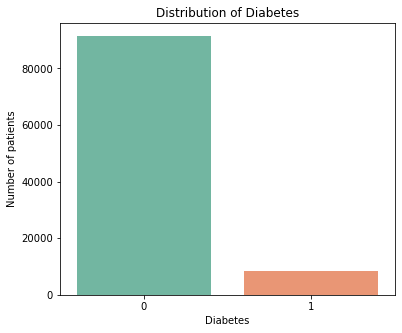

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(x='diabetes', data=df, palette ='Set2')

plt.title("Distribution of Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Number of patients")
plt.show()


#### Purpose

Displays the number of diabetic and non-diabetic patients in the dataset.

This helps us understand whether the target variable is balanced before building machine learning models.

#### Observation

The dataset contains significantly more non-diabetic patients (91.5%) than diabetic patients (8.5%).

The countplot clearly shows that the target variable is highly imbalanced, with non-diabetic cases dominating the dataset.

In [14]:
df["diabetes"].value_counts()

0    91500
1     8500
Name: diabetes, dtype: int64

#### Purpose

Displays the exact number of diabetic and non-diabetic patients.

#### Business Insight

The count provides the actual number of patients in each category, allowing us to measure the degree of class imbalance and evaluate whether additional preprocessing techniques may be needed.

In [15]:
(df["diabetes"].value_counts(normalize = True)*100).round(2)

0    91.5
1     8.5
Name: diabetes, dtype: float64

#### Purpose

Displays the percentage distribution of diabetic and non-diabetic patients.

#### Business Insight

The dataset is highly imbalanced because only 8.5% of patients are diabetic.

If machine learning models are trained directly on this dataset, they may become biased toward predicting the majority class (Non-Diabetic).

This imbalance will be considered during model building, and techniques such as SMOTE or class weighting may be applied if required to improve the prediction of diabetic patients.

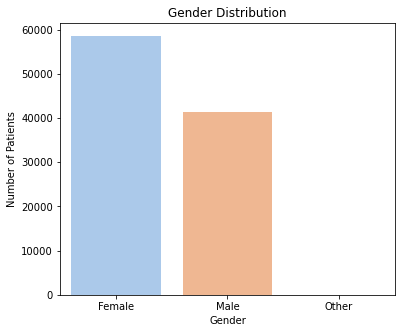

In [16]:

plt.figure(figsize=(6,5))

sns.countplot(x='gender', data=df, palette='pastel')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

#### Purpose

Displays the number of patients belonging to each gender category in the dataset.

This helps us understand the demographic distribution of patients.

#### Business Insight

Understanding gender distribution helps determine whether the dataset is balanced across genders.

A balanced dataset improves the fairness of machine learning models and helps identify whether gender may influence diabetes prediction.

In [17]:
df["gender"].value_counts()

Female    58552
Male      41430
Other        18
Name: gender, dtype: int64

#### Purpose

Displays the exact number of patients in each gender category.

#### Business Insight

The count of each gender helps determine whether one gender is overrepresented in the dataset, which may influence model learning and healthcare analysis.

In [18]:
(df["gender"].value_counts(normalize=True)*100).round(2)

Female    58.55
Male      41.43
Other      0.02
Name: gender, dtype: float64

#### Purpose

Displays the percentage distribution of each gender.

#### Business Insight

The dataset represents both male and female patients, making it suitable for analyzing diabetes risk across genders.

Since both genders are well represented, the machine learning model can learn patterns from both groups. 

However, the "Other" category contains very few records and is unlikely to have a significant impact on model training.

#### Observation

The dataset contains 58.55% female patients and 41.43% male patients.

Only 0.02% of the records belong to the "Other" gender category, indicating that this group has a very small representation in the dataset.

Overall, the dataset has a reasonably balanced distribution between male and female patients, with a slightly higher proportion of females.

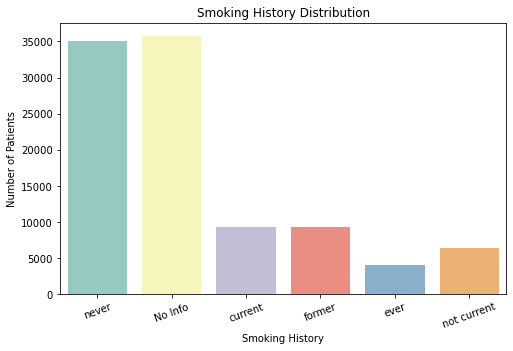

In [19]:

plt.figure(figsize=(8,5))

sns.countplot(x='smoking_history', data=df, palette='Set3')

plt.title("Smoking History Distribution")
plt.xlabel("Smoking History")
plt.ylabel("Number of Patients")

plt.xticks(rotation=20)

plt.show()

#### Purpose

Displays the distribution of patients across different smoking history categories.

This helps understand the lifestyle habits of the patient population.

#### Business Insight

Smoking history is an important lifestyle factor that may influence the risk of developing diabetes.

Since most patients fall under the "Never" or "No Info" categories, additional analysis is required to determine whether smoking habits are associated with diabetes. 

This relationship can be explored later by comparing smoking history with the target variable (diabetes).

In [20]:
df["smoking_history"].value_counts()

No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: smoking_history, dtype: int64

In [21]:
(df["smoking_history"].value_counts(normalize=True)*100).round(2)



No Info        35.82
never          35.10
former          9.35
current         9.29
not current     6.45
ever            4.00
Name: smoking_history, dtype: float64

#### Observation

The majority of patients fall under the "No Info" (35.82%) and "Never" (35.10%) smoking categories.

Current smokers (9.29%) and former smokers (9.35%) represent a moderate proportion of the dataset, while only 4.00% of patients belong to the "Ever" smoking category.

Overall, most patients either have no recorded smoking history or have never smoked.

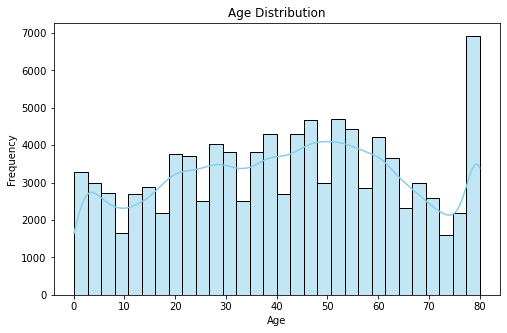

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True, color="skyblue")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

#### Purpose

Displays the distribution of patient ages.

This helps identify the age groups that are most represented in the dataset.

#### Business Insight

Age is one of the most important risk factors for diabetes.

Understanding the age distribution helps determine whether the dataset contains patients from different age groups and supports further analysis of age-related diabetes risk.

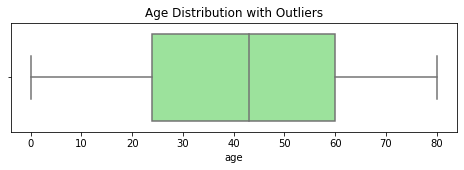

In [23]:
# Age Boxplot

plt.figure(figsize=(8,2))

sns.boxplot(x=df["age"], color="lightgreen")

plt.title("Age Distribution with Outliers")

plt.show()

#### Purpose

Displays the spread of patient ages and helps identify potential outliers.

#### Business Insight

Since no significant outliers are present in the age feature, the data appears to be reliable for model training.

This reduces the need for additional preprocessing related to age and allows the machine learning model to learn from realistic patient age values.

#### Observation

The boxplot indicates that patient ages are distributed within a reasonable range.

No significant outliers are observed, suggesting that the age values are consistent and do not contain unusual or unrealistic observations.

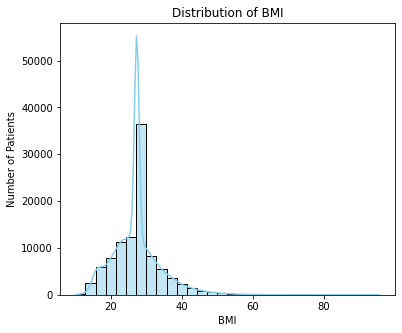

In [24]:
plt.figure(figsize=(6,5))

sns.histplot(df["bmi"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()

#### Purpose

Displays the distribution of Body Mass Index (BMI) among patients.

This helps understand whether most patients have normal, overweight, or obese BMI values.

#### Business Insight

BMI is one of the strongest indicators of diabetes risk.

Understanding the BMI distribution helps healthcare providers identify whether obesity is common in the patient population and whether weight management programs may help reduce diabetes risk.

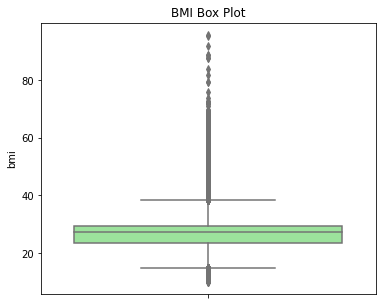

In [25]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["bmi"], color="lightgreen")

plt.title("BMI Box Plot")

plt.show()

#### Purpose

Displays the spread of BMI values and detects possible outliers.

#### Business Insight

Extreme BMI values may represent patients with severe obesity or unusually low body weight.

Identifying these observations helps understand whether special preprocessing or separate medical attention may be required.

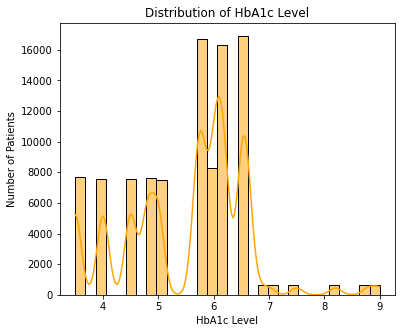

In [26]:
plt.figure(figsize=(6,5))

sns.histplot(df["HbA1c_level"], bins=30, kde=True, color="orange")

plt.title("Distribution of HbA1c Level")
plt.xlabel("HbA1c Level")
plt.ylabel("Number of Patients")

plt.show()

#### Purpose

Shows the distribution of HbA1c levels among patients.

#### Business Insight

HbA1c reflects a patient's average blood sugar level over the past 2–3 months.

Higher HbA1c values generally indicate poorer blood sugar control and a greater likelihood of diabetes.

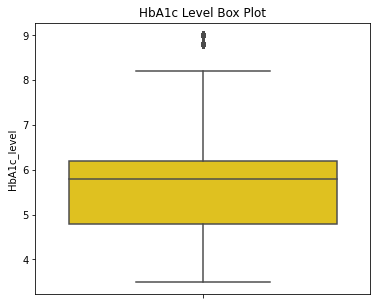

In [27]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["HbA1c_level"], color="gold")

plt.title("HbA1c Level Box Plot")

plt.show()

#### Purpose

Displays the spread of HbA1c values and identifies unusual observations.

#### Business Insight

Patients with exceptionally high HbA1c levels may require immediate clinical intervention.

Detecting these values also helps assess whether outlier treatment is necessary before model building.

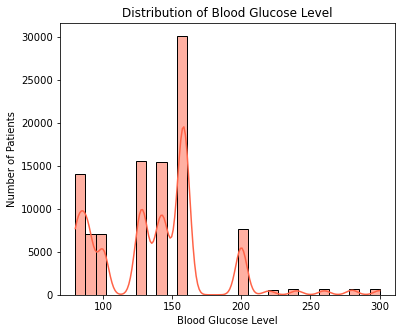

In [28]:
plt.figure(figsize=(6,5))

sns.histplot(df["blood_glucose_level"], bins=30, kde=True, color="tomato")

plt.title("Distribution of Blood Glucose Level")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Number of Patients")

plt.show()

#### Purpose

Shows how blood glucose levels are distributed across patients.

#### Business Insight

Blood glucose level is one of the most important indicators for diagnosing diabetes.

Understanding its distribution helps identify whether a large proportion of patients have elevated glucose levels.

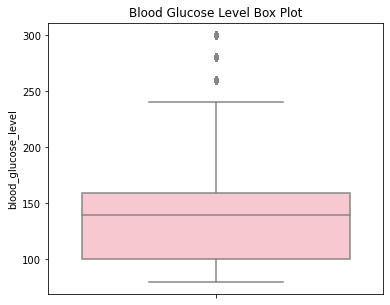

In [29]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["blood_glucose_level"], color="pink")

plt.title("Blood Glucose Level Box Plot")

plt.show()

#### Purpose

Displays the spread of blood glucose values and detects extreme observations.

#### Business Insight

Very high glucose values may indicate uncontrolled diabetes.

Identifying these patients can help healthcare providers prioritize high-risk individuals for immediate treatment.

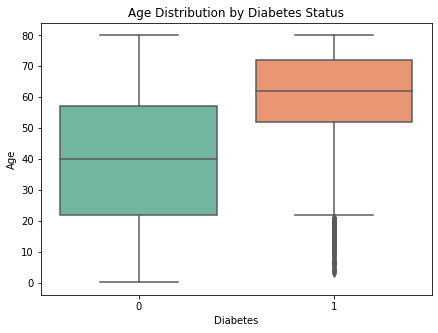

In [30]:
# Diabetes vs Age

plt.figure(figsize=(7,5))

sns.boxplot(x="diabetes",
            y="age",
            data=df,
            palette="Set2")

plt.title("Age Distribution by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Age")

plt.show()

#### Purpose

Shows how the age distribution differs between diabetic and non-diabetic patients.

It helps determine whether diabetes is more common among older individuals.

#### Business Insight

Age is one of the strongest risk factors for diabetes.

If diabetic patients are generally older than non-diabetic patients, healthcare providers can prioritize diabetes screening programs for senior citizens and middle-aged adults.

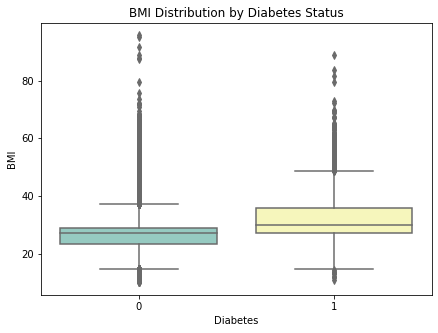

In [31]:
# Diabetes vs BMI

plt.figure(figsize=(7,5))

sns.boxplot(x="diabetes",
            y="bmi",
            data=df,
            palette="Set3")

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("BMI")

plt.show()

#### Purpose

Compares BMI between diabetic and non-diabetic patients.

#### Business Insight

Higher BMI is commonly associated with obesity, which significantly increases diabetes risk.

If diabetic patients show higher BMI values, healthcare organizations can recommend weight management programs to reduce diabetes prevalence.

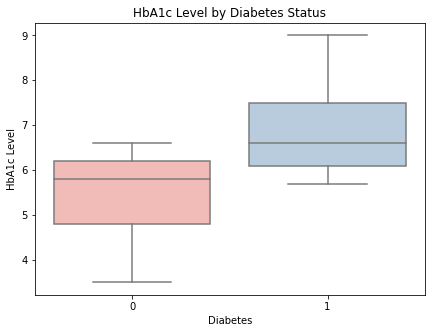

In [32]:
# Diabetes vs HbA1c Level

plt.figure(figsize=(7,5))

sns.boxplot(x="diabetes",
            y="HbA1c_level",
            data=df,
            palette="Pastel1")

plt.title("HbA1c Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c Level")

plt.show()

#### Purpose

Compares HbA1c levels for diabetic and non-diabetic patients.

#### Business Insight

HbA1c measures average blood sugar over the previous three months.

Higher HbA1c values among diabetic patients validate that this feature is highly informative for diabetes prediction and should be an important input to the machine learning model.

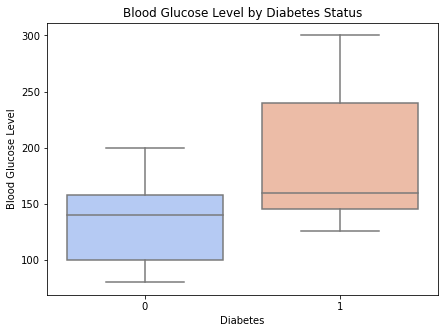

In [33]:
# Diabetes vs Blood Glucose Level

plt.figure(figsize=(7,5))

sns.boxplot(x="diabetes",
            y="blood_glucose_level",
            data=df,
            palette="coolwarm")

plt.title("Blood Glucose Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Blood Glucose Level")

plt.show()

#### Purpose

Compares blood glucose levels between diabetic and non-diabetic patients.

#### Business Insight

Blood glucose level is one of the most direct clinical indicators of diabetes.

A noticeable difference between the two groups confirms that blood glucose is likely to be one of the strongest predictive features in the machine learning model.

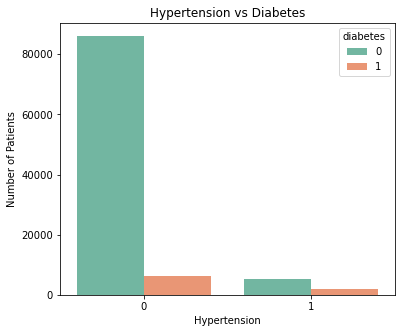

In [34]:
# Hypertension vs Diabetes

plt.figure(figsize=(6,5))

sns.countplot(x="hypertension", data=df, hue="diabetes", palette="Set2")

plt.title("Hypertension vs Diabetes")
plt.xlabel("Hypertension")
plt.ylabel("Number of Patients")

plt.show()

#### Purpose

Displays the number of diabetic and non-diabetic patients based on hypertension status.

This visualization provides an initial comparison between hypertension and diabetes.

#### Business Insight

The graph provides an overview of patient counts across hypertension categories.

Since the dataset contains many more non-diabetic patients than diabetic patients, count comparisons alone may be misleading. 

Therefore, percentage analysis is required to accurately evaluate the relationship between hypertension and diabetes.

In [35]:
df["hypertension"].value_counts()

0    92515
1     7485
Name: hypertension, dtype: int64

#### Purpose

Displays the total number of patients with and without hypertension.

#### Business Insight

Most patients do not have hypertension, while only a small proportion have hypertension.

This indicates that hypertension is less common in the patient population.

In [36]:
(df["hypertension"].value_counts(normalize=True)*100).round(2)

0    92.52
1     7.48
Name: hypertension, dtype: float64

#### Purpose

Displays the percentage distribution of patients with and without hypertension.

#### Business Insight

Percentage values provide a better understanding of how common hypertension is among patients.

A low percentage indicates that hypertension is relatively uncommon in the dataset, while a higher percentage suggests it is a significant health concern that should be considered during model development.

In [37]:
(df["hypertension"].value_counts(normalize=True)*100).round(2)  # Percentage Distribution

0    92.52
1     7.48
Name: hypertension, dtype: float64

#### Purpose

Displays the percentage distribution of hypertension status.

#### Business Insight

Approximately 92.52% of patients do not have hypertension, whereas only 7.48% have hypertension.

This indicates that hypertension affects a relatively small portion of the patient population.

In [38]:
(pd.crosstab(df["hypertension"],df["diabetes"],normalize="index")*100).round(2)

diabetes,0,1
hypertension,,
0,93.07,6.93
1,72.10,27.90


#### Purpose

Calculates the percentage of diabetic and non-diabetic patients within each hypertension category.

This removes the effect of unequal group sizes and helps compare diabetes prevalence fairly between patients with and without hypertension.

#### Observation

Patients without hypertension have a diabetes prevalence of 6.93%.

In contrast, patients with hypertension have a diabetes prevalence of 27.90%.

This indicates that diabetes is considerably more common among patients diagnosed with hypertension.

#### Business Insight 

Patients with hypertension have a much higher prevalence of diabetes compared to patients without hypertension.

Only 6.93% of patients without hypertension are diabetic, whereas 27.90% of patients with hypertension are diabetic.

This indicates a strong association between hypertension and diabetes, suggesting that hypertension is an important risk factor for developing diabetes.

From a healthcare perspective, patients diagnosed with hypertension should undergo regular diabetes screening to enable early detection and timely treatment.

From a machine learning perspective, hypertension is expected to be an important predictive feature for diabetes classification.

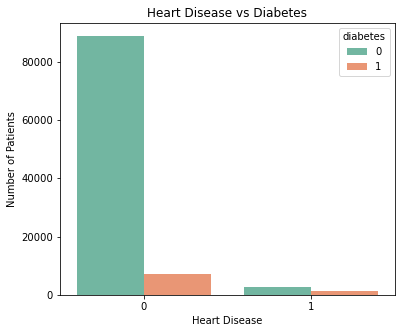

In [39]:
#### Heart Disease vs Diabetes

plt.figure(figsize=(6,5))

sns.countplot(x="heart_disease", data=df, hue="diabetes", palette="Set2")

plt.title("Heart Disease vs Diabetes")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

#### Purpose

Displays the distribution of diabetic and non-diabetic patients based on heart disease status.

This visualization provides an initial comparison between heart disease and diabetes before performing percentage-based analysis.

#### Business Insight

The countplot provides an overall comparison of diabetic and non-diabetic patients across heart disease categories.

Since the dataset contains significantly more non-diabetic patients than diabetic patients, the graph alone cannot accurately explain the relationship between heart disease and diabetes. Therefore, percentage-based analysis using Crosstab is required for meaningful interpretation.

In [40]:
df["heart_disease"].value_counts()

0    96058
1     3942
Name: heart_disease, dtype: int64

#### Purpose

Displays the total number of patients with and without heart disease.

This helps understand the prevalence of heart disease within the dataset.

#### Business Insight

The dataset contains a very small proportion of patients with heart disease compared to those without heart disease.

This indicates that heart disease is relatively uncommon in the patient population.

In [41]:
(df["heart_disease"].value_counts(normalize=True)*100).round(2) # Percentage Distribution

0    96.06
1     3.94
Name: heart_disease, dtype: float64

#### Purpose

Displays the percentage distribution of patients with and without heart disease.

Percentage analysis helps evaluate how common heart disease is within the dataset.

#### Business Insight

Only 3.94% of patients have heart disease, while 96.06% do not.

Although heart disease affects a relatively small portion of the population, it remains an important medical condition because it is closely associated with several chronic diseases, including diabetes.

In [42]:
(pd.crosstab(df["heart_disease"],df["diabetes"],normalize="index")*100).round(2)

diabetes,0,1
heart_disease,,
0,92.47,7.53
1,67.86,32.14


#### Purpose

Calculates the percentage of diabetic and non-diabetic patients within each heart disease category.

Unlike countplots, Crosstab removes the effect of unequal group sizes, allowing a fair comparison of diabetes prevalence.

#### Observation

Patients without heart disease have a diabetes prevalence of 7.53%.

In contrast, patients with heart disease have a diabetes prevalence of 32.14%.

This shows that diabetes is considerably more common among patients diagnosed with heart disease.

#### Business Insight

Patients with heart disease have a significantly higher prevalence of diabetes compared to patients without heart disease.

While only 7.53% of patients without heart disease are diabetic, 32.14% of patients with heart disease are diabetic.

This strong association suggests that heart disease is an important risk factor for diabetes and is expected to be a valuable predictive feature in the machine learning model.

From a healthcare perspective, patients with heart disease should undergo regular diabetes screening to enable early diagnosis and better disease management.

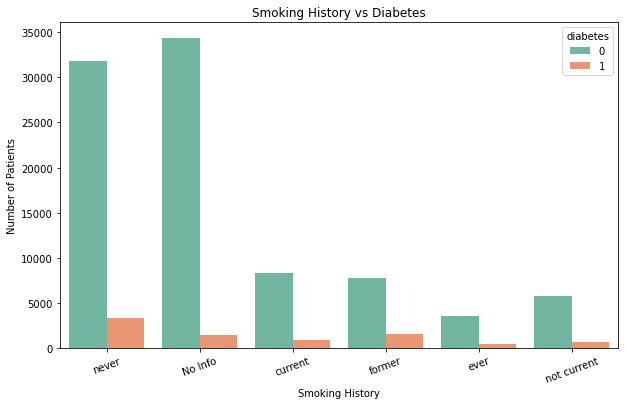

In [43]:
# Smoking History vs Diabetes

plt.figure(figsize=(10,6))

sns.countplot(x="smoking_history",
              data=df,
              hue="diabetes",
              palette="Set2")

plt.title("Smoking History vs Diabetes")
plt.xlabel("Smoking History")
plt.ylabel("Number of Patients")

plt.xticks(rotation=20)

plt.show()

#### Purpose 

Displays the distribution of diabetic and non-diabetic patients across different smoking history categories.

This visualization provides an initial comparison between smoking history and diabetes.

#### Business Insight

The countplot provides an overview of diabetes distribution across different smoking history categories.

Since each smoking category contains a different number of patients, percentage-based analysis is required to accurately understand the relationship between smoking history and diabetes.

In [44]:
df["smoking_history"].value_counts()

No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: smoking_history, dtype: int64

#### Purpose

Displays the total number of patients in each smoking history category.

This helps identify the most common smoking behaviors among patients in the dataset.

#### Business Insight

The majority of patients belong to the "No Info" (35.82%) and "Never" (35.10%) smoking categories, indicating that most patients either have no recorded smoking history or have never smoked.

The remaining categories, including Former, Current, Not Current, and Ever smokers, represent a smaller proportion of the patient population.

In [45]:
(df["smoking_history"].value_counts(normalize=True)*100).round(2)# Percentage Distribution

No Info        35.82
never          35.10
former          9.35
current         9.29
not current     6.45
ever            4.00
Name: smoking_history, dtype: float64

#### Purpose

Displays the percentage distribution of patients across different smoking history categories.

Percentage analysis provides a better understanding of the prevalence of each smoking behavior within the patient population.

#### Business Insight

More than 70% of patients fall under the "No Info" and "Never" smoking categories.

This suggests that most patients either have no documented smoking history or have never smoked, while active and former smokers represent a smaller proportion of the dataset.

In [46]:
(pd.crosstab(df["smoking_history"],df["diabetes"],normalize="index")*100).round(2)

diabetes,0,1
smoking_history,,
No Info,95.94,4.06
current,89.79,10.21
ever,88.21,11.79
former,83.00,17.00
never,90.47,9.53
not current,89.30,10.70


#### Purpose
Calculates the percentage of diabetic and non-diabetic patients within each smoking history category.

Unlike countplots, Crosstab removes the effect of unequal group sizes, allowing a fair comparison of diabetes prevalence across different smoking behaviors.

#### Observation

Patients with a "Former" smoking history have the highest diabetes prevalence (17.00%), followed by "Ever" smokers (11.79%).

Current smokers (10.21%), Not Current smokers (10.70%), and Never smokers (9.53%) show moderate diabetes prevalence.

Patients with "No Info" smoking history have the lowest diabetes prevalence (4.06%).

Patients with no recorded smoking history show the lowest observed diabetes prevalence; however, this category represents missing lifestyle information and should be interpreted with caution

#### Business Insight
Smoking history appears to be associated with diabetes prevalence.

Former smokers show the highest percentage of diabetes (17.00%), suggesting that individuals with a history of smoking may remain at higher risk of developing diabetes even after quitting.

Current smokers (10.21%) and Ever smokers (11.79%) also exhibit higher diabetes prevalence than patients with no recorded smoking history.

These findings indicate that smoking history can be considered a valuable lifestyle-related feature for diabetes prediction and should be included in the machine learning model.

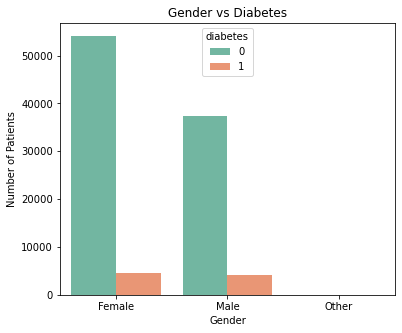

In [47]:
# Gender vs Diabetes

plt.figure(figsize=(6,5))

sns.countplot(x="gender",
              data=df,
              hue="diabetes",
              palette="Set2")

plt.title("Gender vs Diabetes")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

#### Purpose
Displays the distribution of diabetic and non-diabetic patients across different gender categories.

This visualization provides an initial comparison of diabetes prevalence among different genders before performing percentage-based analysis.

#### Business Insight
The countplot provides an overall comparison of diabetic and non-diabetic patients across different gender categories.

Since the number of patients differs between genders, countplots alone cannot accurately compare diabetes prevalence. Therefore, percentage-based analysis using Crosstab is required.

In [48]:
df["gender"].value_counts()

Female    58552
Male      41430
Other        18
Name: gender, dtype: int64

#### Purpose
Displays the total number of patients belonging to each gender category.

This helps understand the gender distribution within the dataset.

#### Business Insight
The dataset contains a higher proportion of female patients (58.55%) compared to male patients (41.43%), while the "Other" category represents only a very small number of patients (0.02%).

This indicates that the dataset is predominantly composed of female patients.

In [49]:
(df["gender"].value_counts(normalize=True)*100).round(2) # Percentage Distribution

Female    58.55
Male      41.43
Other      0.02
Name: gender, dtype: float64

#### Purpose
Displays the percentage distribution of patients across different gender categories.

Percentage analysis provides a clearer understanding of gender representation within the dataset.

#### Business Insight
Female patients constitute the majority of the dataset, followed by male patients.

The "Other" gender category contains very few observations and therefore contributes minimally to the overall analysis.

In [50]:
(pd.crosstab(df["gender"],df["diabetes"],normalize="index")*100).round(2)

diabetes,0,1
gender,,
Female,92.38,7.62
Male,90.25,9.75
Other,100.00,0.00


#### Purpose
Calculates the percentage of diabetic and non-diabetic patients within each gender category.

Unlike countplots, Crosstab removes the effect of unequal group sizes, allowing a fair comparison of diabetes prevalence across genders.

#### Observation
Male patients have a diabetes prevalence of 9.75%, whereas female patients have a diabetes prevalence of 7.62%.

The "Other" gender category shows no diabetic patients; however, this category contains only 18 observations, making it too small to draw meaningful conclusions.

#### Business Insight
The percentage analysis indicates that diabetes prevalence is slightly higher among male patients (9.75%) compared to female patients (7.62%).

Although gender shows some association with diabetes, the difference is relatively small compared to stronger predictors such as hypertension and heart disease.

Therefore, gender should be retained as a supporting feature in the machine learning model, while greater importance should be given to clinical factors such as hypertension, heart disease, HbA1c level, blood glucose level, BMI, and age.

#### Professional Summary
The Exploratory Data Analysis (EDA) provided valuable insights into the characteristics of the healthcare dataset and identified several factors associated with diabetes.

The target variable analysis revealed that the dataset is imbalanced, with non-diabetic patients significantly outnumbering diabetic patients. This imbalance should be considered during model development and evaluation.

The age distribution showed that patient ages are spread across a wide range without significant outliers, indicating that age data is reliable for analysis. Since age is a well-known risk factor for diabetes, it is expected to contribute to the prediction model.

BMI, HbA1c level, and blood glucose level contained noticeable outliers. However, these outliers represent genuine medical observations rather than data entry errors. Therefore, they should be retained because they carry important clinical information.

Categorical analysis revealed several important relationships with diabetes:

 Patients with hypertension showed a much higher diabetes prevalence (27.90%) compared to patients without hypertension (6.93%).

 Patients with heart disease also had a considerably higher diabetes prevalence (32.14%) than patients without heart disease (7.53%).

 Smoking history analysis indicated that former smokers had the highest diabetes prevalence (17.00%), followed by ever smokers (11.79%), suggesting that smoking history may influence diabetes risk.

 Male patients exhibited a slightly higher diabetes prevalence (9.75%) than female patients (7.62%). However, the difference was relatively small compared to clinical risk factors.

Overall, the EDA suggests that hypertension, heart disease, HbA1c level, blood glucose level, BMI, and age are likely to be the most influential predictors of diabetes. These findings provide a strong foundation for feature selection, data preprocessing, and machine learning model development.


#### Business Conclusion
The analysis indicates that diabetes is strongly associated with several clinical and lifestyle-related factors.

Patients diagnosed with hypertension and heart disease demonstrate substantially higher diabetes prevalence, highlighting the importance of regular diabetes screening among these high-risk groups.

Similarly, patients with a history of smoking, particularly former smokers, exhibit higher diabetes prevalence, emphasizing the need for lifestyle modification programs and preventive healthcare initiatives.

The findings also confirm that medical indicators such as HbA1c level, blood glucose level, BMI, and age are expected to play a significant role in predicting diabetes.

These insights can help healthcare organizations identify high-risk individuals, implement targeted preventive measures, improve early diagnosis, and optimize resource allocation for diabetes management programs.

#### Machine Learning Perspective

Based on the Exploratory Data Analysis, all selected features contain meaningful information related to diabetes prediction.

Numerical variables such as age, BMI, HbA1c level, and blood glucose level demonstrate strong clinical relevance, while categorical variables including hypertension, heart disease, smoking history, and gender provide additional predictive information.

The dataset is free from missing values and duplicate records, making it suitable for machine learning model development.

The next phase of the project will focus on data preprocessing, feature encoding, train-test splitting, feature scaling, model training, and performance evaluation to develop an accurate diabetes prediction model.

In [51]:
# Selecting Independent and Dependent Variables (Feature Selection)

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

#### Purpose

Separates the dataset into:

Independent Variables (X): Features used to predict diabetes.

Dependent Variable (y): The target variable that the model will learn to predict.

#### Business Insight

The machine learning model should learn patterns from patient information such as age, BMI, hypertension, heart disease, smoking history, HbA1c level, blood glucose level, and gender to predict whether a patient is diabetic.

Separating features and the target variable is the first step in supervised machine learning.

In [52]:
X.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,never,25.19,6.6,140
1,Female,54.0,0,0,No Info,27.32,6.6,80
2,Male,28.0,0,0,never,27.32,5.7,158
3,Female,36.0,0,0,current,23.45,5.0,155
4,Male,76.0,1,1,current,20.14,4.8,155


#### Purpose

Displays the first five rows of the independent variables to verify that the target column has been successfully removed.

#### Business Insight

Verifying the feature dataset ensures that only predictor variables are used for model training, preventing data leakage from the target variable.

In [53]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

#### Purpose

Displays the first five values of the target variable.

#### Business Insight

This confirms that the target variable has been correctly isolated and is ready for supervised learning.

In [54]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

X.head()

y.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

In [55]:
y.tail()

99995    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, dtype: int64

In [56]:
y.value_counts()

0    91500
1     8500
Name: diabetes, dtype: int64

In [57]:
y.value_counts(normalize=True) * 100

0    91.5
1     8.5
Name: diabetes, dtype: float64

#### Business Insight

The target variable is imbalanced, with 91.5% non-diabetic patients and only 8.5% diabetic patients.

This class imbalance can bias machine learning models toward predicting the majority class. 

Therefore, evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will be more informative than accuracy alone when assessing model performance.

In [58]:
df[df["diabetes"] == 1].head() #This confirms that the dataset definitely contains diabetic patients.

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
6,Female,44.0,0,0,never,19.31,6.5,200,1
26,Male,67.0,0,1,not current,27.32,6.5,200,1
38,Male,50.0,1,0,current,27.32,5.7,260,1
40,Male,73.0,0,0,former,25.91,9.0,160,1
53,Female,53.0,0,0,former,27.32,7.0,159,1


In [59]:
# One-Hot Encoding

X = pd.get_dummies(
    X,
    columns=["gender", "smoking_history"],
    drop_first=True
)

X.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,1,0,1,0,0,0,0


#### Purpose
Converts categorical variables into numerical format using One-Hot Encoding, making the dataset suitable for machine learning algorithms.

#### Business Insight
Machine learning algorithms require numerical input to identify patterns and relationships within the data.

One-Hot Encoding transforms categorical features such as gender and smoking history into numerical variables while preserving their original information and avoiding artificial ranking among categories.

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

#### Purpose
Splits the dataset into training and testing sets.

The training dataset is used to train the machine learning model, while the testing dataset is used to evaluate the model's performance on unseen data.

#### Business Insight
Separating the data into training and testing sets ensures that the model is evaluated on unseen patient records rather than the same data it was trained on.

This provides a realistic estimate of how accurately the model can predict diabetes for new patients in real-world healthcare settings.


In [63]:
print("Training Features (X_train):", X_train.shape)
print("Testing Features (X_test):", X_test.shape)
print("Training Target (y_train):", y_train.shape)
print("Testing Target (y_test):", y_test.shape)

Training Features (X_train): (80000, 13)
Testing Features (X_test): (20000, 13)
Training Target (y_train): (80000,)
Testing Target (y_test): (20000,)


#### Purpose
Displays the number of rows and columns in the training and testing datasets after splitting.

This confirms that the data has been divided correctly.

#### Business Insight
Splitting the data into training and testing sets ensures that the model is evaluated on unseen patient records rather than the same data it was trained on.

This provides a realistic estimate of how accurately the model can predict diabetes for new patients in real-world healthcare settings.

In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler = StandardScaler() # Create the scaler object

#### Purpose

Creates a StandardScaler object to standardize numerical features.

#### Business Insight

Scaling ensures that features with larger values (such as blood glucose level) do not dominate features with smaller values (such as HbA1c level) during model training.

In [66]:
X_train = scaler.fit_transform(X_train) # Fit and Transform the Training Data

#### Purpose

Calculates the mean and standard deviation from the training data and scales the training dataset.

#### Business Insight

The model learns only from the training data, preventing information leakage from the testing dataset.

In [67]:
X_test = scaler.transform(X_test) # Transform the Testing Data

#### Purpose

Uses the same scaling parameters learned from the training data to standardize the testing dataset.

#### Business Insight

Applying identical scaling ensures that the model evaluates unseen patient records under the same conditions as the training data, resulting in fair and reliable performance evaluation.

In [69]:
X_train[:5]

array([[ 1.37871976, -0.28630923, -0.20355869, -0.38647449, -1.89245106,
        -1.42515661,  1.18734314, -0.01414355, -0.31885797, -0.20419058,
         3.10684138, -0.73511021, -0.26293117],
       [ 1.68986587, -0.28630923, -0.20355869, -0.41217229,  0.16216906,
         0.17059059,  1.18734314, -0.01414355, -0.31885797, -0.20419058,
        -0.32187031,  1.36034024, -0.26293117],
       [-0.17701075, -0.28630923, -0.20355869, -0.45298645, -1.42549194,
         0.48974003, -0.84221652, -0.01414355, -0.31885797,  4.8973855 ,
        -0.32187031, -0.73511021, -0.26293117],
       [-0.71040407, -0.28630923, -0.20355869, -1.27833936, -0.4915737 ,
        -0.93415747, -0.84221652, -0.01414355, -0.31885797, -0.20419058,
        -0.32187031, -0.73511021,  3.80327674],
       [ 0.84532644,  3.49272702, -0.20355869, -0.7885695 , -0.95853282,
        -1.30240682, -0.84221652, -0.01414355,  3.13619254, -0.20419058,
        -0.32187031, -0.73511021, -0.26293117]])

In [70]:
X_test[:5]

array([[-1.28824683, -0.28630923, -0.20355869, -0.98357046,  0.25556089,
        -0.29585859, -0.84221652, -0.01414355, -0.31885797, -0.20419058,
        -0.32187031, -0.73511021, -0.26293117],
       [-1.73274126, -0.28630923, -0.20355869, -0.95636103, -0.4915737 ,
         0.17059059, -0.84221652, -0.01414355, -0.31885797, -0.20419058,
        -0.32187031, -0.73511021, -0.26293117],
       [ 0.93422533, -0.28630923, -0.20355869, -0.30333454, -1.89245106,
         1.52083822,  1.18734314, -0.01414355, -0.31885797, -0.20419058,
         3.10684138, -0.73511021, -0.26293117],
       [-1.77719071, -0.28630923, -0.20355869, -1.49601486,  0.53573636,
        -0.29585859, -0.84221652, -0.01414355, -0.31885797, -0.20419058,
        -0.32187031,  1.36034024, -0.26293117],
       [-0.39925797, -0.28630923, -0.20355869,  1.92783928,  0.62912818,
         1.52083822, -0.84221652, -0.01414355, -0.31885797, -0.20419058,
        -0.32187031, -0.73511021,  3.80327674]])

In [72]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Model
lr = LogisticRegression(random_state=42)

# Train Model
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.959

Confusion Matrix
[[18126   166]
 [  654  1054]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



#### Purpose

Logistic Regression was implemented as the baseline classification model to predict whether a patient is diabetic or non-diabetic based on demographic, lifestyle, and clinical health indicators.

The model was trained using the training dataset and evaluated on unseen testing data to assess its predictive performance.

#### Business Insight

The Logistic Regression model achieved an overall accuracy of 95.9%, indicating excellent predictive performance on unseen patient data.

The model correctly classified the majority of diabetic and non-diabetic patients, demonstrating that patient characteristics such as age, BMI, HbA1c level, blood glucose level, hypertension, heart disease, gender, and smoking history contain valuable information for diabetes prediction.

This model serves as a strong baseline and provides a benchmark for comparing more advanced machine learning algorithms.

#### Observation

The Logistic Regression model achieved an overall accuracy of 95.9%, indicating strong predictive performance.

The model correctly identified most non-diabetic patients and demonstrated high precision (86%) for predicting diabetic patients.

However, the recall value of 62% indicates that a considerable number of diabetic patients were missed during prediction.

In healthcare applications, minimizing false negatives is particularly important because undiagnosed diabetic patients may not receive timely medical intervention.

Therefore, although Logistic Regression provides a strong baseline model, algorithms with higher recall should be explored to improve diabetes detection.

#### Business Conclusion
The Logistic Regression model can effectively assist healthcare professionals in identifying patients at risk of diabetes.

While the model demonstrates excellent overall accuracy, improving recall should be a priority to ensure that fewer diabetic patients remain undetected.

In medical decision-making, correctly identifying high-risk patients is often more important than achieving the highest overall accuracy.

Therefore, additional machine learning models such as Decision Tree and Random Forest will be evaluated to determine whether they can improve diabetes detection while maintaining strong overall performance.

In [73]:
# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Model
dt = DecisionTreeClassifier(random_state=42)

# Train Model
dt.fit(X_train, y_train)

# Prediction
y_pred_dt = dt.predict(X_test)

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy :", accuracy_dt)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.95195

Confusion Matrix
[[17775   517]
 [  444  1264]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18292
           1       0.71      0.74      0.72      1708

    accuracy                           0.95     20000
   macro avg       0.84      0.86      0.85     20000
weighted avg       0.95      0.95      0.95     20000



#### Purpose

Decision Tree Classifier was implemented to classify patients as diabetic or non-diabetic by learning decision rules from patient health features.

The model identifies patterns in demographic, lifestyle, and clinical variables to make diabetes predictions on unseen patient data.

#### Business Insight
The Decision Tree model achieved an overall accuracy of 95.20%, demonstrating strong predictive capability for diabetes classification.

The model effectively learns complex relationships between patient characteristics such as age, BMI, HbA1c level, blood glucose level, hypertension, heart disease, gender, and smoking history. Its tree-based structure also makes it easier to interpret which factors influence diabetes prediction.

####  Observation
The Decision Tree model achieved an overall accuracy of 95.20%, which is slightly lower than Logistic Regression (95.90%).

However, the Decision Tree achieved a higher Recall (74%) compared to Logistic Regression (62%), meaning it successfully identified more diabetic patients.

Although Precision decreased from 86% to 71%, the improved Recall is valuable in healthcare applications because correctly detecting diabetic patients is more important than maximizing overall accuracy.

Therefore, the Decision Tree model demonstrates better sensitivity for diabetes detection while maintaining strong overall predictive performance.

#### Business Conclusion
The Decision Tree model provides an effective approach for identifying diabetic patients by capturing complex relationships among clinical and lifestyle factors.

Compared to Logistic Regression, the Decision Tree identifies a greater proportion of diabetic patients, making it more suitable for healthcare scenarios where early disease detection is a priority.

Although the model generates more false positive predictions, these are generally less critical than missing actual diabetic patients. Therefore, the Decision Tree represents a strong candidate for diabetes prediction, particularly when maximizing patient detection is the primary objective.

In [74]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Model
rf = RandomForestClassifier(random_state=42)

# Train Model
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy :", accuracy_rf)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.96995

Confusion Matrix
[[18226    66]
 [  535  1173]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



#### Purpose 

Random Forest Classifier was implemented to predict whether a patient is diabetic or non-diabetic by combining multiple decision trees into a single ensemble model.

The algorithm improves prediction accuracy and reduces overfitting by aggregating the predictions of several decision trees, resulting in a more robust and reliable classification model.

#### Business Insight
The Random Forest model achieved excellent predictive performance by learning complex relationships among patient demographics, lifestyle factors, and clinical measurements.

Its ensemble learning approach provides more stable and accurate predictions compared to a single Decision Tree, making it highly suitable for supporting early diabetes risk identification in healthcare organizations.

#### Observation
The Random Forest model achieved the highest overall accuracy (96.99%) among all evaluated models.

It also produced the highest Precision (95%) and the highest F1-Score (80%), indicating excellent overall classification performance.

Although its Recall (69%) is slightly lower than the Decision Tree model (74%), Random Forest significantly reduced false positive predictions while maintaining strong diabetic patient detection.

Overall, the Random Forest model demonstrates the best balance between accuracy, precision, recall, and F1-score, making it the most reliable model evaluated for diabetes prediction.

#### Business Conclusion
The Random Forest model provides the most balanced and reliable performance for predicting diabetes.

Its high accuracy and excellent precision indicate that healthcare professionals can have strong confidence in positive diabetes predictions while minimizing unnecessary follow-up examinations for healthy patients.

Although the Decision Tree identified slightly more diabetic patients, the Random Forest achieved superior overall performance by balancing prediction accuracy and diabetic patient detection.

Based on the evaluation results, Random Forest is recommended as the final model for supporting early diabetes prediction and assisting healthcare professionals in preventive screening programs.

In [76]:
# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,HbA1c_level,0.397138
5,blood_glucose_level,0.329611
3,bmi,0.121995
0,age,0.100404
1,hypertension,0.014600
2,heart_disease,0.010685
6,gender_Male,0.007010
11,smoking_history_never,0.005169
10,smoking_history_former,0.004357
8,smoking_history_current,0.003233


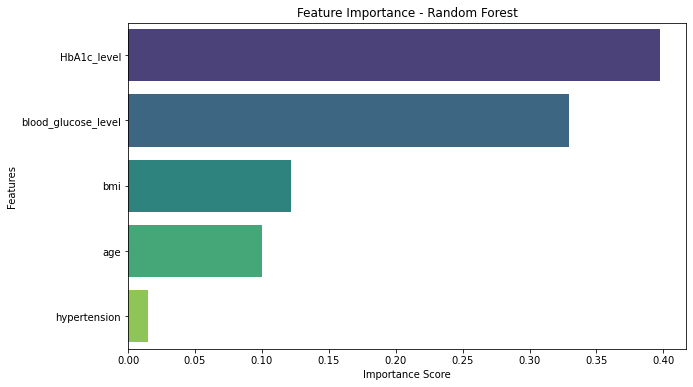

In [82]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(),
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

#### Purpose

Identifies the most influential features contributing to diabetes prediction using the Random Forest model.

#### Business Insight

Feature Importance helps healthcare professionals understand which patient characteristics have the greatest impact on diabetes prediction, enabling more focused screening and preventive healthcare strategies.

In [78]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        95.90,
        95.20,
        96.99
    ],

    "Precision":[
        86,
        71,
        95
    ],

    "Recall":[
        62,
        74,
        69
    ],

    "F1 Score":[
        72,
        72,
        80
    ]

})comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,95.90,86,62,72
1,Decision Tree,95.20,71,74,72
2,Random Forest,96.99,95,69,80


#### Purpose

Compares the performance of different machine learning models using evaluation metrics.

#### Business Insight

Comparing multiple machine learning models helps identify the most reliable algorithm for diabetes prediction. Based on the evaluation metrics, Random Forest achieved the highest overall performance and is recommended for deployment in healthcare decision-support systems.

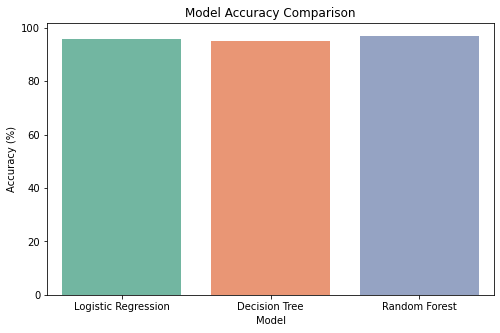

In [79]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison,
    palette="Set2"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

#### Purpose

Visualizes the performance of different machine learning models.

#### Business Insight

The comparison chart provides a quick overview of model performance and helps select the most reliable model for deployment.

#### Final Conclusion
1. A comprehensive exploratory data analysis was performed to understand patient demographics, lifestyle factors, and clinical health indicators.

2. Three machine learning algorithms were implemented: Logistic Regression, Decision Tree, and Random Forest.

3. Random Forest achieved the highest overall accuracy of 96.99% and the highest F1-score, making it the best-performing model.

4. Blood Glucose Level, HbA1c Level, BMI, and Age were identified as the most influential features for diabetes prediction.

5. The developed predictive model can support early diagnosis, reduce the risk of diabetes complications, and assist healthcare professionals in making data-driven clinical decisions.

#### Business Recommendations
* Conduct regular diabetes screening for patients with high blood glucose and HbA1c levels.

* Prioritize preventive healthcare programs for patients with hypertension and heart disease.

* Promote healthy lifestyle awareness among smokers to reduce diabetes risk.

* Encourage periodic BMI monitoring and weight management programs.

* Deploy the Random Forest model as a decision-support tool for early diabetes detection in hospitals and healthcare centers.
* Encourage regular health check-ups for individuals above 40 years of age and patients with hypertension or heart disease.

#### Future Scope
• Deploy the model as a web application using Flask or Streamlit.

• Integrate the model with hospital management systems.

• Train the model on larger and more diverse healthcare datasets.

• Develop a real-time diabetes risk prediction system.

• Extend the project to predict diabetes severity and long-term complications.

#### Overall Project Summary
• Successfully analyzed a diabetes prediction dataset containing 100,000 patient records.

• Performed Exploratory Data Analysis (EDA) to understand patient demographics, medical history, and health indicators.

• Applied data preprocessing techniques including One-Hot Encoding and Train-Test Split.

• Built three machine learning models:
  - Logistic Regression
  - Decision Tree
  - Random Forest

• Compared model performance using Accuracy, Precision, Recall, and F1-Score.

• Random Forest achieved the highest accuracy (96.99%) and was selected as the final model.

• Feature Importance analysis identified HbA1c Level, Blood Glucose Level, BMI, and Age as the strongest predictors of diabetes.

• The developed model can support early diabetes prediction and improve preventive healthcare decision-making.